# Создание цикла обучения

Data loader 

In [1]:
import os
import torch
import pandas as pd
from torchvision.io import decode_image
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2


1. Создание кастомного класса для загрузки данных

In [18]:
class MNISTDataset(Dataset):
    def __init__(self, annotations_file, transforms = v2.ToDtype(torch.float32, scale=True) , target_transform = F.one_hot):
        df = pd.read_csv(annotations_file)
        self.img_labels , self.image = df['label'], df.drop(columns='label')
        self.target_transform = target_transform
        self.transform = transforms

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        label = self.img_labels.iloc[idx]
        image = torch.tensor(self.image.iloc[idx].values, dtype= torch.uint8 )
        image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(torch.tensor(label),num_classes=10).float()
        return image, label

2. Деление на тестовыи и треин данные 

In [19]:
from torch.utils.data import random_split , DataLoader
data = MNISTDataset('fashion-mnist_test.csv')
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))
test_size = len(data) - train_size - val_size

train_data, val_data, test_data = random_split(
    data, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
val_loader =  DataLoader(val_data, batch_size = 64, shuffle = False)
test_loader =  DataLoader(test_data, batch_size = 64, shuffle = False)


In [20]:
for X, y in test_loader:
    print(f"Shape of X [N, C, H, W]: {X.shape},  {X.dtype}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 784]),  torch.float32
Shape of y: torch.Size([64, 10]) torch.float32


то есть всё хорошо поделилось на батчи и данные уже преведены в формат 2D с которым принято работать для данного датасета , а вектор ответов преобразован в 10 векторов с значением 0 или 1 при помощи one hot encoding 

3. Создание модели

In [21]:
from torch import nn
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256, 10))
        
    def forward(self,x):
        logits = self.linear_relu(x)
        return logits
    

model = MNISTModel()
print(model)

MNISTModel(
  (linear_relu): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


Let's check model's correct

In [22]:
input = torch.rand([16,784], dtype= torch.float32)
print((model(input)).shape)

torch.Size([16, 10])


Chosing loss function and optimisator 

In [23]:
from torch.optim import Adam 

loss_cross_entr = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr = 1e-3)

In [24]:
print(train_loader)

In [25]:
from torch.optim.lr_scheduler import CosineAnnealingLR
lr_cheduler_cos = CosineAnnealingLR(opt, 
                                    T_max= 40,
                                    eta_min= 1e-6)

Model traning

In [26]:
from torch.autograd import backward
train_loss = []
val_loss = []
list_cos = []

EPOCHS = 40 
for epoch in range(EPOCHS):

    model.train()
    running_train_loss = []
    for x, target in train_loader:
        pred = model(x)
        loss = loss_cross_entr(pred, target)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running_train_loss.append(loss.item())

    lr_cheduler_cos.step()
    list_cos.append(lr_cheduler_cos.get_last_lr()[0])
    mean_tr_loss = sum(running_train_loss) / len(running_train_loss)
    train_loss.append(mean_tr_loss)

    model.eval()
    running_val_loss = []
    with torch.no_grad():
        for x, target in val_loader:
            pred = model(x)
            loss = loss_cross_entr(pred, target)
            running_val_loss.append(loss.item())

    mean_val_loss = sum(running_val_loss) / len(running_val_loss)
    val_loss.append(mean_val_loss)

    print(f'{epoch+1}/{EPOCHS}, train loss = {mean_tr_loss:.4f}, val loss = {mean_val_loss:.4f}')

1/40, train loss = 0.8799, val loss = 0.6360
2/40, train loss = 0.5461, val loss = 0.5512
3/40, train loss = 0.4558, val loss = 0.5119
4/40, train loss = 0.4240, val loss = 0.4435
5/40, train loss = 0.3800, val loss = 0.4608
6/40, train loss = 0.3555, val loss = 0.4317
7/40, train loss = 0.3313, val loss = 0.4550
8/40, train loss = 0.3166, val loss = 0.4418
9/40, train loss = 0.2855, val loss = 0.4199
10/40, train loss = 0.2689, val loss = 0.4137
11/40, train loss = 0.2504, val loss = 0.4291
12/40, train loss = 0.2317, val loss = 0.4563
13/40, train loss = 0.2157, val loss = 0.4089
14/40, train loss = 0.2099, val loss = 0.4175
15/40, train loss = 0.1937, val loss = 0.4222
16/40, train loss = 0.1812, val loss = 0.4334
17/40, train loss = 0.1707, val loss = 0.4197
18/40, train loss = 0.1599, val loss = 0.4352
19/40, train loss = 0.1485, val loss = 0.4462
20/40, train loss = 0.1341, val loss = 0.4628
21/40, train loss = 0.1299, val loss = 0.4466
22/40, train loss = 0.1110, val loss = 0.49

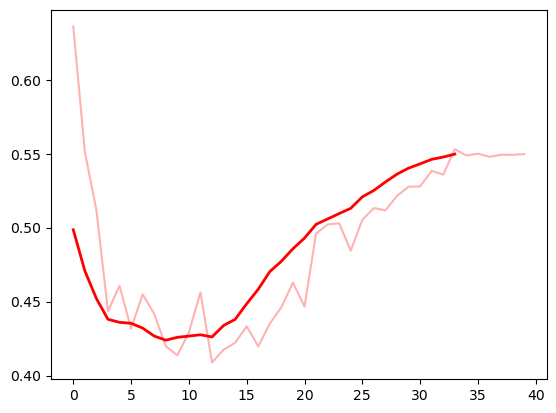

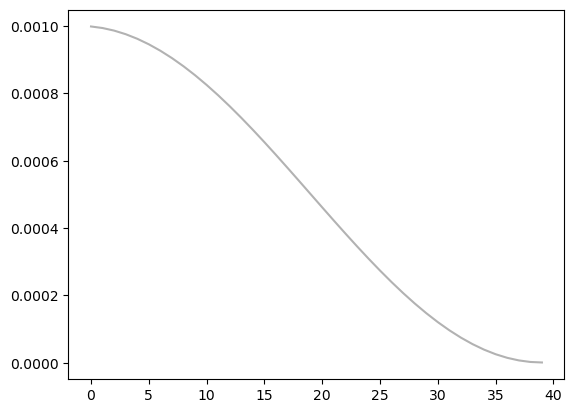

In [38]:
import numpy as np
import matplotlib.pyplot as plt


def smooth(values, window=5):
    return np.convolve(values, np.ones(window)/window, mode='valid')

# В цикле обучения собираешь loss

# При построении графика
epochs = range(len(val_loss))
smooth_loss = smooth(val_loss, window=7)

plt.plot(epochs, val_loss, alpha=0.3, color='red', label='Loss (raw)')
plt.plot(range(len(smooth_loss)), smooth_loss, color='red', linewidth=2, label='Loss (smooth)')
plt.show()
plt.plot(epochs, list_cos, alpha=0.3, color='black')


до этого проводила тренировку просто с маленькими шагами не исполюзуя cheduler и результаты получались на порядок лучше